In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Degradado horizontal: 5 valores de 0 a 255, repetidos en 5 filas
gris = np.tile(np.linspace(0, 255, 5), (5, 1))

print("shape:", gris.shape)
print("dtype:", gris.dtype)
print("mean:", gris.mean())

shape: (5, 5)
dtype: float64
mean: 127.5


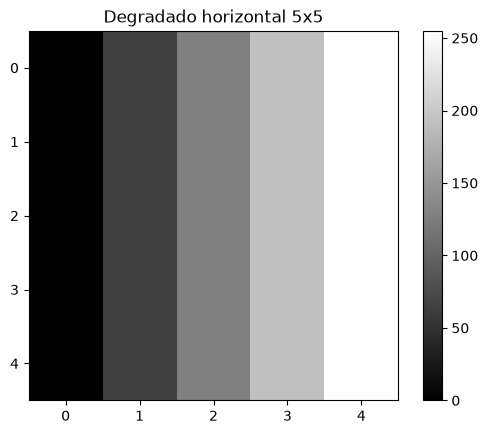

In [11]:
plt.imshow(gris, cmap="gray", vmin=0, vmax=255)
plt.colorbar()
plt.title("Degradado horizontal 5x5")
plt.savefig("gris_tema6.png")
plt.show()

In [12]:
# Todas las filas, últimas 3 columnas (índices 2, 3 y 4)
recorte = gris[:, 2:]
print(recorte)

[[127.5  191.25 255.  ]
 [127.5  191.25 255.  ]
 [127.5  191.25 255.  ]
 [127.5  191.25 255.  ]
 [127.5  191.25 255.  ]]


In [13]:
# Imagen 4x4 con 3 canales, inicia toda en negro
rgb = np.zeros((4, 4, 3), dtype=np.uint8)

rgb[:, 0:2] = [255, 0, 0]   # mitad izquierda: rojo
rgb[:, 2:4] = [0, 255, 0]   # mitad derecha: verde

print(rgb.shape)
print("Pixel [0,0]:", rgb[0, 0])
print("Pixel [0,3]:", rgb[0, 3])

(4, 4, 3)
Pixel [0,0]: [255   0   0]
Pixel [0,3]: [  0 255   0]


In [14]:
R = rgb[:, :, 0]
G = rgb[:, :, 1]
B = rgb[:, :, 2]

print("Canal R:\n", R)
print("Canal G:\n", G)
print("Canal B:\n", B)

Canal R:
 [[255 255   0   0]
 [255 255   0   0]
 [255 255   0   0]
 [255 255   0   0]]
Canal G:
 [[  0   0 255 255]
 [  0   0 255 255]
 [  0   0 255 255]
 [  0   0 255 255]]
Canal B:
 [[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]


In [15]:
# Promedio simple de los 3 canales
gris_promedio = rgb.mean(axis=2)

# Luminosidad ponderada
gris_luminosidad = 0.299 * R + 0.587 * G + 0.114 * B

print("Promedio:\n", gris_promedio)
print("Luminosidad:\n", gris_luminosidad)

Promedio:
 [[85. 85. 85. 85.]
 [85. 85. 85. 85.]
 [85. 85. 85. 85.]
 [85. 85. 85. 85.]]
Luminosidad:
 [[ 76.245  76.245 149.685 149.685]
 [ 76.245  76.245 149.685 149.685]
 [ 76.245  76.245 149.685 149.685]
 [ 76.245  76.245 149.685 149.685]]


In [16]:
umbral = 113
binaria = (gris_luminosidad > umbral).astype(np.uint8) * 255

print(binaria)

[[  0   0 255 255]
 [  0   0 255 255]
 [  0   0 255 255]
 [  0   0 255 255]]


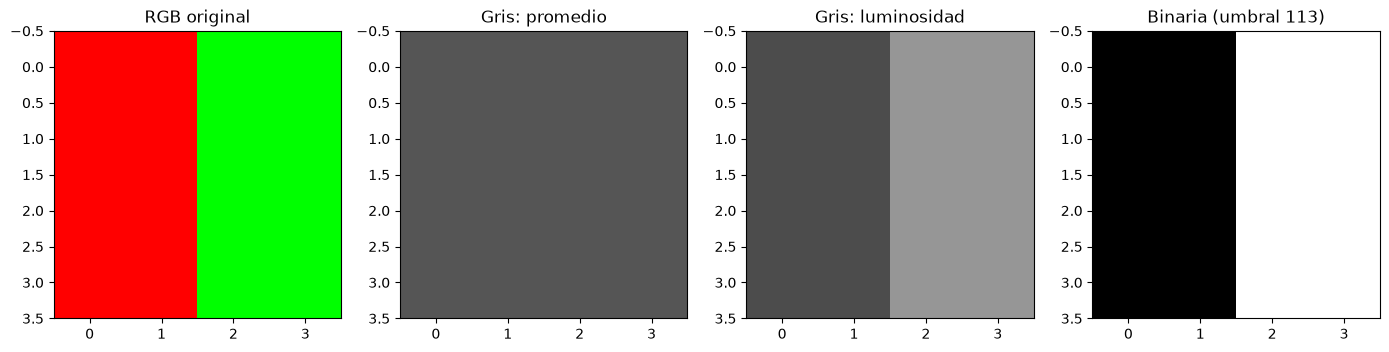

In [17]:
fig, ax = plt.subplots(1, 4, figsize=(14, 3.5))

ax[0].imshow(rgb)
ax[0].set_title("RGB original")

ax[1].imshow(gris_promedio, cmap="gray", vmin=0, vmax=255)
ax[1].set_title("Gris: promedio")

ax[2].imshow(gris_luminosidad, cmap="gray", vmin=0, vmax=255)
ax[2].set_title("Gris: luminosidad")

ax[3].imshow(binaria, cmap="gray", vmin=0, vmax=255)
ax[3].set_title(f"Binaria (umbral {umbral})")

plt.tight_layout()
plt.show()